In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import sklearn.linear_model as skl
import sklearn.metrics as skl_m
from catboost import CatBoostRegressor

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [2]:
np.random.seed(0)
random.seed(0)

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [4]:
# Load datasets
train_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [5]:
print(train_data.shape, test_data.shape)

(1460, 81) (1459, 80)


In [6]:
check = train_data.isnull().sum()
check[check > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [7]:
test_data.drop(["Id", "Alley", "MasVnrArea", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"], axis = 1, inplace = True)
train_data.drop(["Id", "Alley", "MasVnrArea", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"], axis = 1, inplace = True)

In [8]:
print(train_data.shape, test_data.shape)

(1460, 74) (1459, 73)


In [9]:
train_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [10]:
floats = []
objects = []

for col_name, data in train_data.items():
    if train_data.dtypes[col_name] == 'object':
        objects.append(col_name) 
    elif train_data.dtypes[col_name] == 'float64' or train_data.dtypes[col_name] == 'int':
        floats.append(col_name) 

In [11]:
for name in floats:
    train_data[name] = train_data[name].fillna(train_data[name].mean())
    if name != "SalePrice":
        test_data[name] = test_data[name].fillna(test_data[name].mean())
for name in objects:
    train_data[name] = train_data[name].fillna(train_data[name].value_counts().index[0])
    test_data[name] = test_data[name].fillna(test_data[name].value_counts().index[0])

In [12]:
corr_matrix = train_data[floats].corr()

<Axes: >

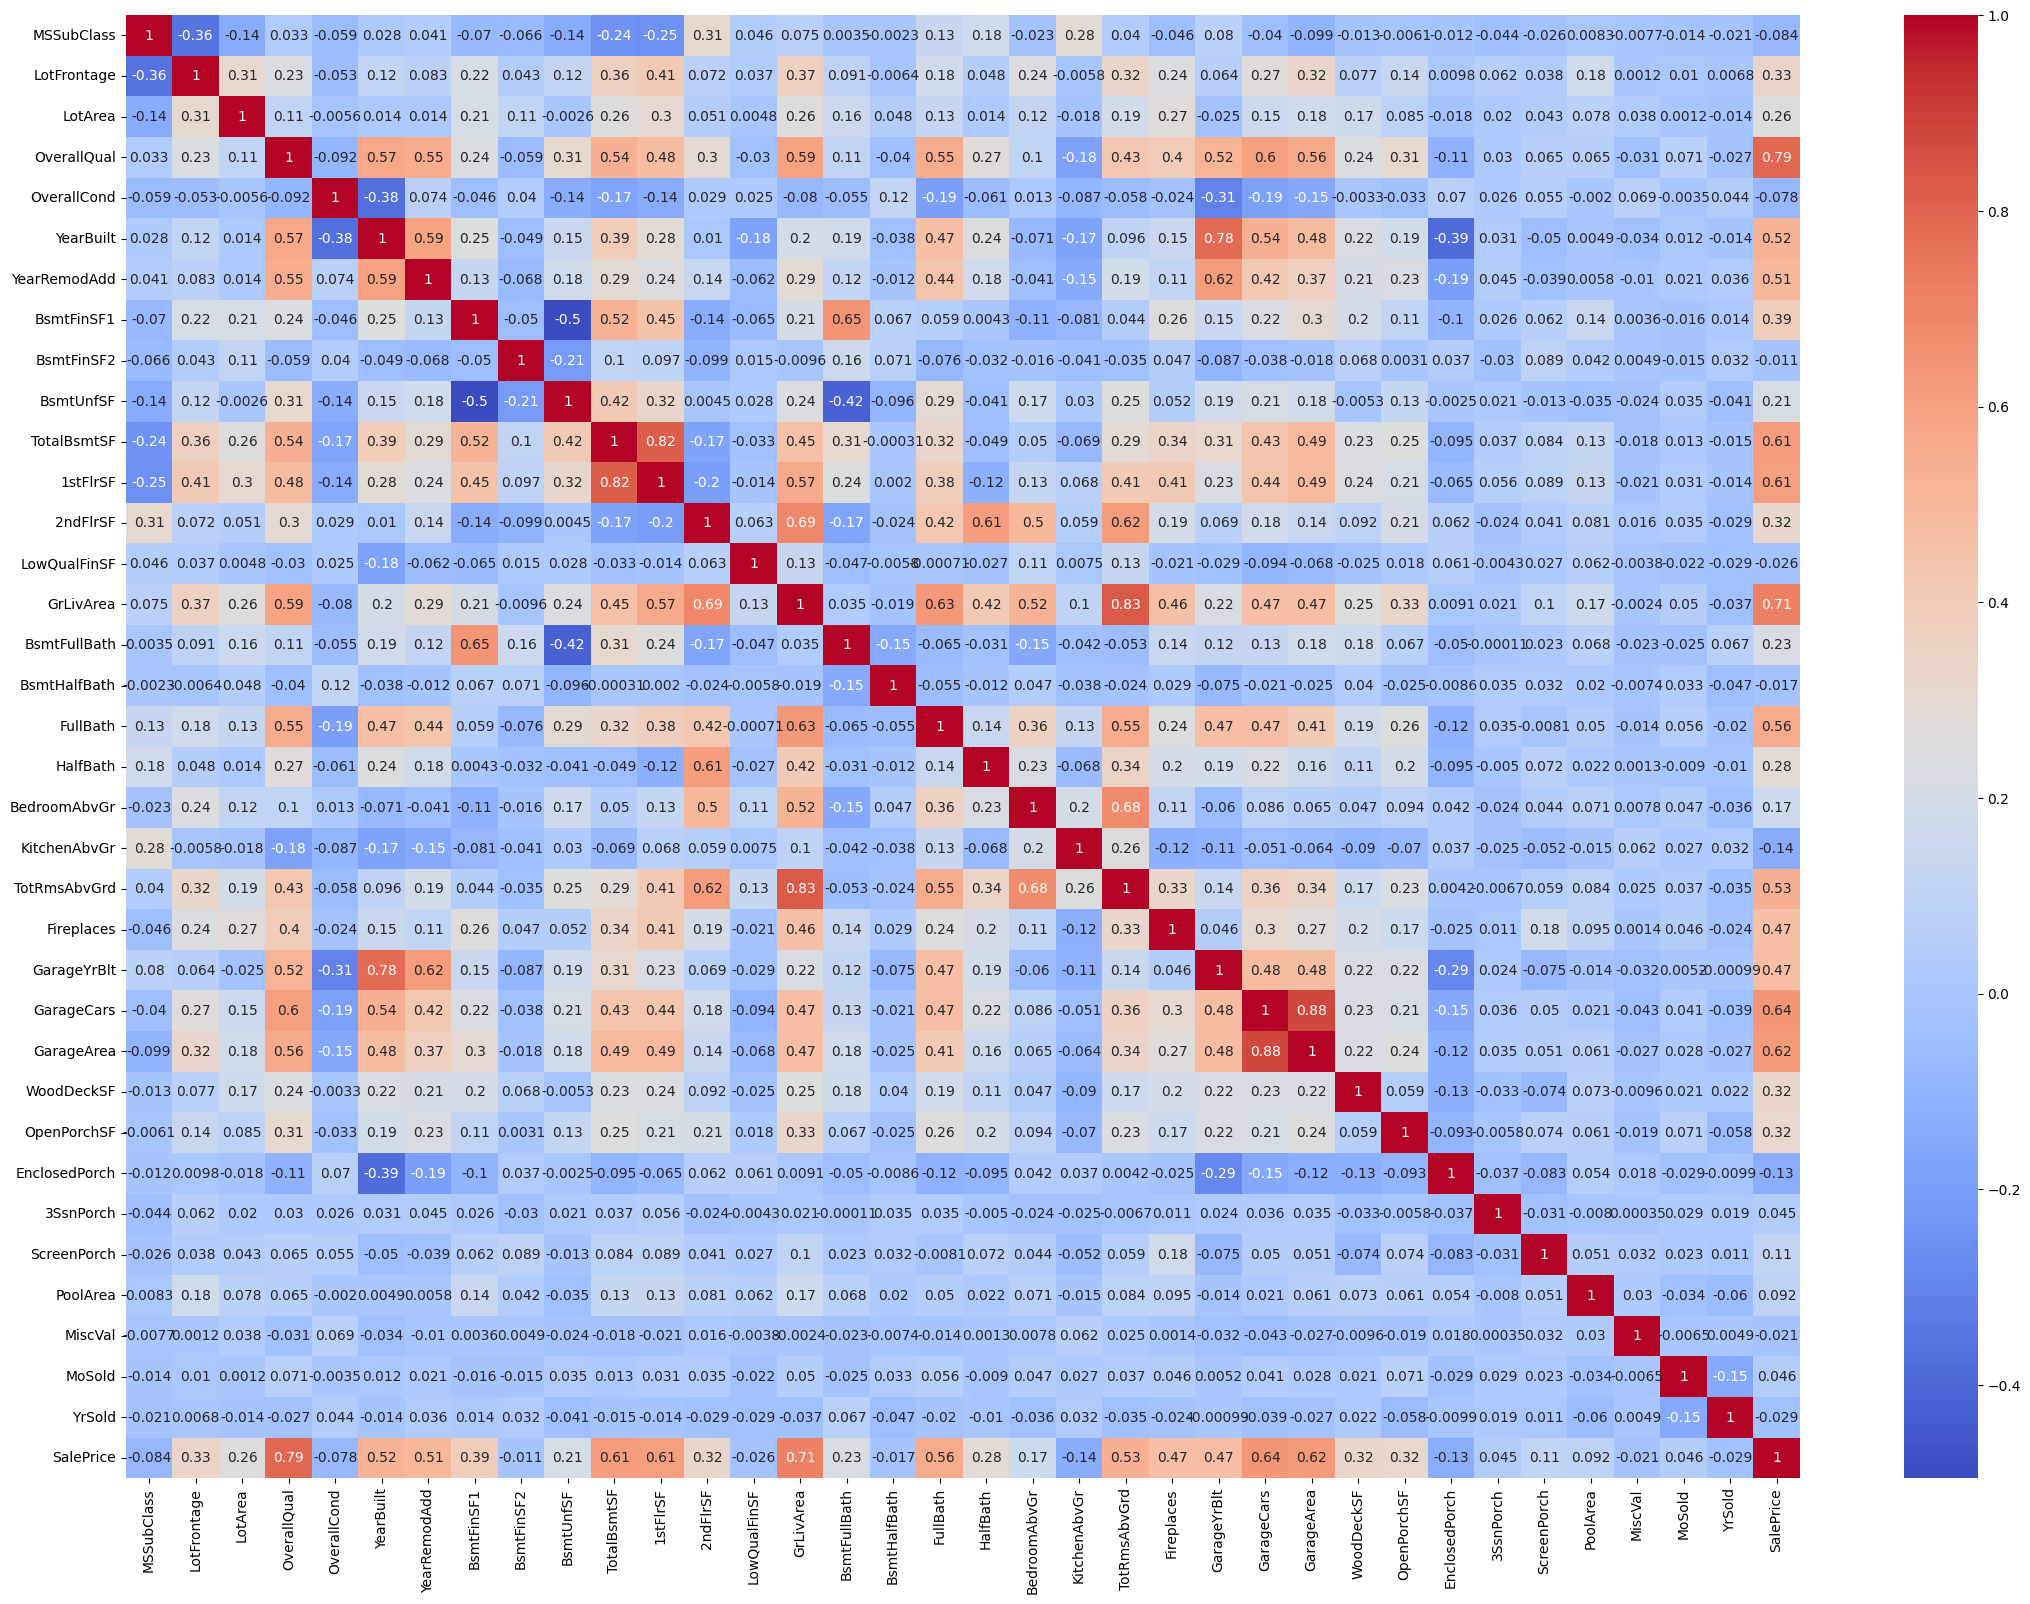

In [13]:
plt.figure(figsize = (27,19))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt = '.2g')

In [14]:
drop = corr_matrix["SalePrice"][abs(corr_matrix["SalePrice"]) < 0.1].index
drop

Index(['MSSubClass', 'OverallCond', 'BsmtFinSF2', 'LowQualFinSF',
       'BsmtHalfBath', '3SsnPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [15]:
test_data.drop(drop, axis = 1, inplace = True)
train_data.drop(drop, axis = 1, inplace = True)

In [16]:
LE_arr = []
OHE_arr = []

for obj in objects:
    if train_data[obj].nunique() != 2 and test_data[obj].nunique() == train_data[obj].nunique():
        LE_arr.append(obj)
    else:
        LE_arr.append(obj)


In [17]:
for obj in objects:
    train_data[obj] = LabelEncoder().fit_transform(train_data[obj])
    test_data[obj] = LabelEncoder().fit_transform(test_data[obj])

In [18]:
#train_data = pd.get_dummies(train_data, columns=OHE_arr, dtype = int)
#test_data = pd.get_dummies(test_data, columns=OHE_arr, dtype = int)
#print(train_data.shape, test_data.shape)

In [19]:
train_data_d = train_data.drop("SalePrice", axis = 1)
scaler = preprocessing.StandardScaler().fit(train_data_d)
train_data_n = scaler.transform(train_data_d)
test_data_n = scaler.transform(test_data)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(train_data_n, train_data["SalePrice"], test_size=0.15, random_state=42, shuffle=True)

In [21]:
#X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, shuffle=True)

In [22]:
#HouseReg = skl.SGDRegressor(alpha = 0.001, max_iter = 100000, penalty = "elasticnet")
#HouseReg = skl.HuberRegressor(epsilon=1.0, max_iter = 10000)
#HouseReg = skl.Lasso(alpha=1, max_iter = 1000)
#HouseReg = skl.Ridge(alpha=0.01, max_iter = 1000)
HouseReg = CatBoostRegressor(iterations=5000,
                        learning_rate=0.1,
                        #loss_function='Huber',
                        #model_size_reg = 'LogCosh',
                        depth=6,
                        task_type='GPU',
                        devices='0')
HouseReg.fit(X_train, y_train)

0:	learn: 72130.7131171	total: 203ms	remaining: 16m 57s
1:	learn: 67468.6099158	total: 216ms	remaining: 9m
2:	learn: 63267.3104356	total: 229ms	remaining: 6m 21s
3:	learn: 59599.6507798	total: 242ms	remaining: 5m 2s
4:	learn: 56210.3219805	total: 255ms	remaining: 4m 14s
5:	learn: 53126.4902572	total: 268ms	remaining: 3m 42s
6:	learn: 50498.4005582	total: 280ms	remaining: 3m 20s
7:	learn: 48046.5097819	total: 293ms	remaining: 3m 3s
8:	learn: 45716.5128335	total: 306ms	remaining: 2m 49s
9:	learn: 43712.5768323	total: 318ms	remaining: 2m 38s
10:	learn: 42129.0371891	total: 330ms	remaining: 2m 29s
11:	learn: 40570.4694538	total: 342ms	remaining: 2m 21s
12:	learn: 39138.3801251	total: 353ms	remaining: 2m 15s
13:	learn: 37742.0466422	total: 365ms	remaining: 2m 9s
14:	learn: 36554.6667055	total: 377ms	remaining: 2m 5s
15:	learn: 35465.7795139	total: 389ms	remaining: 2m 1s
16:	learn: 34463.8680188	total: 400ms	remaining: 1m 57s
17:	learn: 33691.4394625	total: 412ms	remaining: 1m 54s
18:	learn:

In [23]:
y_pred = HouseReg.predict(X_test)

In [24]:
MSE = skl_m.mean_squared_error(y_pred, y_test)
MAE = skl_m.mean_absolute_error(y_pred, y_test)
RMSE = MSE**0.5

In [25]:
print(MSE, MAE, RMSE)

769523735.0146713 17581.92193175029 27740.29082426266


19483.029864973214

In [26]:
pred = HouseReg.predict(test_data_n)

In [27]:
submission = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")
submission["SalePrice"] = pred
submission = submission.to_csv("submission.csv",index=False)